This notebook replicates the ClusterDE [PBMC vignette](https://songdongyuan1994.github.io/ClusterDE/articles/ClusterDE-PBMC.html) using scdesigner. That vignette clusters PBMCs with Seurat pipeline and compares cluster 2 vs. 8 which are both monocytes (specifically CD14+ and FCGR3A+) but clearly demarcated cell clusters. We used `scanpy.datasets.pbmc3k` instead of `pbmc` in Seurat.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
from clusterde_py import find_markers

CLUSTER_RESOLUTION = 0.3
N_CLUSTERING_HVGS = 2000
FDR = 0.05
SEED = 0

First we load the data and cluster it with a standard scanpy pipeline, simialr to the vignette's Seurat pipeline.

In [2]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_counts=100)

cdata = adata.copy()
sc.pp.normalize_total(cdata, target_sum=1e4)
sc.pp.log1p(cdata)
sc.pp.highly_variable_genes(cdata, n_top_genes=N_CLUSTERING_HVGS)

hvg = cdata[:, cdata.var.highly_variable].copy()
sc.pp.scale(hvg, max_value=10)
sc.tl.pca(hvg, n_comps=10, svd_solver="arpack", random_state=SEED)
sc.pp.neighbors(hvg, n_neighbors=10, random_state=SEED)
sc.tl.leiden(hvg, resolution=CLUSTER_RESOLUTION, flavor="igraph", n_iterations=2, random_state=SEED)

cdata.obs["leiden"] = hvg.obs["leiden"].values
adata.obs["leiden"] = hvg.obs["leiden"].values
cdata.obs["leiden"].value_counts()

leiden
3    719
4    525
0    449
2    361
1    359
6    159
5    116
7     12
Name: count, dtype: int64

Next we look for the CD14+ and FCGR3A+ monocyte clusters through their marker genes, similar to the vignette's cluster-tree selection.

In [3]:
expr = sc.get.obs_df(cdata, keys=["CD14", "FCGR3A"])
expr["leiden"] = cdata.obs["leiden"].values
means = expr.groupby("leiden", observed=True).mean()

cd14_cluster = means["CD14"].idxmax()
cd16_cluster = means.drop(index=cd14_cluster)["FCGR3A"].idxmax()
print(f"CD14+ classical monocyte cluster: {cd14_cluster!r}")
print(f"FCGR3A+/CD16+ non-classical monocyte cluster: {cd16_cluster!r}")

GROUP1 = "CD14+ Monocytes"
GROUP2 = "FCGR3A+ Monocytes"
adata.obs["monocyte_type"] = adata.obs["leiden"].map({cd14_cluster: GROUP1, cd16_cluster: GROUP2})
adata_filtered = adata[adata.obs["monocyte_type"].notna()].copy()
adata_filtered.obs["monocyte_type"] = adata_filtered.obs["monocyte_type"].astype("category")

CD14+ classical monocyte cluster: '4'
FCGR3A+/CD16+ non-classical monocyte cluster: '6'


Next we run a standard marker gene analysis (log normalize + Wilcoxon) without any ClusterDE synthetic null control.

In [4]:
naive = adata_filtered.copy()
sc.pp.normalize_total(naive)
sc.pp.log1p(naive)
sc.tl.rank_genes_groups(
    naive, "monocyte_type", groups=[GROUP1], reference=GROUP2, method="wilcoxon"
)
naive_df = sc.get.rank_genes_groups_df(naive, GROUP1)
naive_df = naive_df[naive_df["logfoldchanges"] > 0]
naive_significant = naive_df.loc[naive_df["pvals_adj"] <= FDR, "names"]

Next we run ClusterDE.

In [5]:
result = find_markers(
    adata_filtered,
    "monocyte_type",
    GROUP1,
    GROUP2,
    fdr=FDR,
    null_kwargs={"seed": SEED, "fit_kwargs": {"max_epochs": 100, "top_k": 50}},
    cluster_kwargs={"seed": SEED},
)
clusterde_significant = result[result["is_DE"]]

result

Epoch 100/100, Loss: 0.6337, Val Loss: 0.6258


Estimating top-k copula correlation: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,
LGALS2,4.083884e-58,1.448133e-01,56.549735,0.360892,False
S100A9,1.462148e-53,2.914117e-01,52.299516,0.360892,False
S100A8,7.235895e-55,1.687766e-03,51.367820,0.360892,False
GPX1,2.551971e-45,4.197724e-02,43.216138,0.360892,False
LYZ,1.799216e-74,6.858005e-33,41.581114,0.360892,False
...,...,...,...,...,...
RPS6,1.140937e-03,5.633887e-58,-54.306454,1.000000,False
RPL10,1.195979e-10,4.238553e-68,-57.450506,1.000000,False
RPS12,3.380327e-02,5.685334e-62,-59.774203,1.000000,False


These genes were found significant in the naive marker gene analysis.

In [6]:
naive_significant

0           LYZ
1        LGALS2
2        S100A8
3        S100A9
4          GPX1
         ...   
123        CD36
124        FUOM
125         IL8
126        FPR1
127    SERPINB1
Name: names, Length: 128, dtype: object

After running ClusterDE, only a handful remain significant.

In [7]:
clusterde_significant

,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,


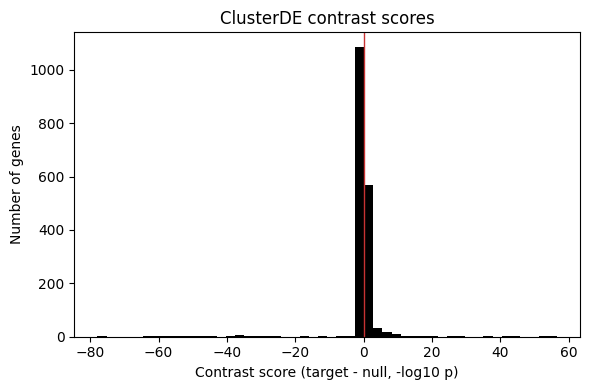

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(result["contrast_score"], bins=50, color="black")
ax.axvline(0, color="#C73333", linewidth=1)
ax.set_xlabel("Contrast score (target - null, -log10 p)")
ax.set_ylabel("Number of genes")
ax.set_title(f"ClusterDE contrast scores")
fig.tight_layout()
fig.show()